In [1]:
import practicalSPARQL
import pandas as pd
import ast
import matplotlib.pyplot as plt
import numpy as np
import bqplot as bq
import geopandas as gpd
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.patches as mpatches
import networkx as nx
from itertools import combinations
import os

In [2]:
df = pd.read_csv('../DATA/02_image_clusters/full_image_data_feb_25.csv')
books = pd.read_csv('../DATA/01_corpus_metadata/full_book_data_feb_25.csv')
ucks = pd.read_excel('../DATA/03_content_keywords/all_elements_all_ck_ucks.xlsx')

In [3]:
# Assuming your DataFrame is named ucks
ucks = ucks[ucks['level'] != 0]


In [4]:

#adding printer and publisher data from "books" to "df"
df['printer'] = df['book'].map(books.set_index('book')['printers'])
df['publisher'] = df['book'].map(books.set_index('book')['publishers'])

#for each images values in df, add the its uck value from "ucks" df
df_merged = df.merge(
    ucks[['label', 'uck']],
    how='left',
    left_on='cluster_name',
    right_on='label'
).drop(columns='label')


In [5]:
# df_merged

In [6]:
# Print all unique uck values
print(df_merged['uck'].unique())


['Astronomy' 'Geocentric Cosmology' 'Shape and Dimensions of the Cosmos'
 'Sublunar World' 'Planetary Astronomy' 'DISCIPLINES' 'Moon'
 'Position of the Earth' 'Shape of the Earth' 'The Cosmos as a whole'
 'Superlunar World'
 'General Geometry and Principles of Planetary Movements' 'Venus'
 'Three superior planets' 'Mercury' 'Astrology' 'PRACTICAL ACTIVITIES'
 'Shape of the Heavens' 'Optics' 'Geometric Subjects' 'Geometry'
 'The four elements' 'Relations between the Elements of Water and Earth'
 'Observer Perspective' 'Instrumental Geometric Demonstrations'
 'Rising and Setting of Stars' 'Relations Between Celestial Bodies'
 'Ascensions' 'Astronomy of the Eighth Sphere'
 'Movement of the Eighth Sphere' 'Sun' 'Subdivisions of the Cosmos'
 'Division of the Cosmos by the Signs' 'Celestial circles'
 'Metrics of the surface of the Earth'
 'Relations Between Earth and Cosmos' 'Cosmography and Geography'
 'Cartography' 'Dimensions of the Earth' 'Definition of Sphere'
 'Great Circles at Differe

In [7]:
# Images that belong to DISCIPLINES
disciplines_images = df_merged[df_merged['uck'].str.contains('DISCIPLINES', case=False)]['images'].unique()
disciplines_count = len(disciplines_images)

# Images that belong to PRACTICAL ACTIVITIES
practical_images = df_merged[df_merged['uck'].str.contains('PRACTICAL ACTIVITIES', case=False)]['images'].unique()
practical_count = len(practical_images)

# Unique images that do NOT belong to either DISCIPLINES or PRACTICAL ACTIVITIES
all_disc_prac_images = set(disciplines_images) | set(practical_images)
other_unique_images_count = df_merged[~df_merged['images'].isin(all_disc_prac_images)]['images'].nunique()

# Print results
print("Unique images in DISCIPLINES:", disciplines_count)
print("Unique images in PRACTICAL ACTIVITIES:", practical_count)
print("Unique images NOT in DISCIPLINES or PRACTICAL ACTIVITIES:", other_unique_images_count)


Unique images in DISCIPLINES: 19741
Unique images in PRACTICAL ACTIVITIES: 2363
Unique images NOT in DISCIPLINES or PRACTICAL ACTIVITIES: 353


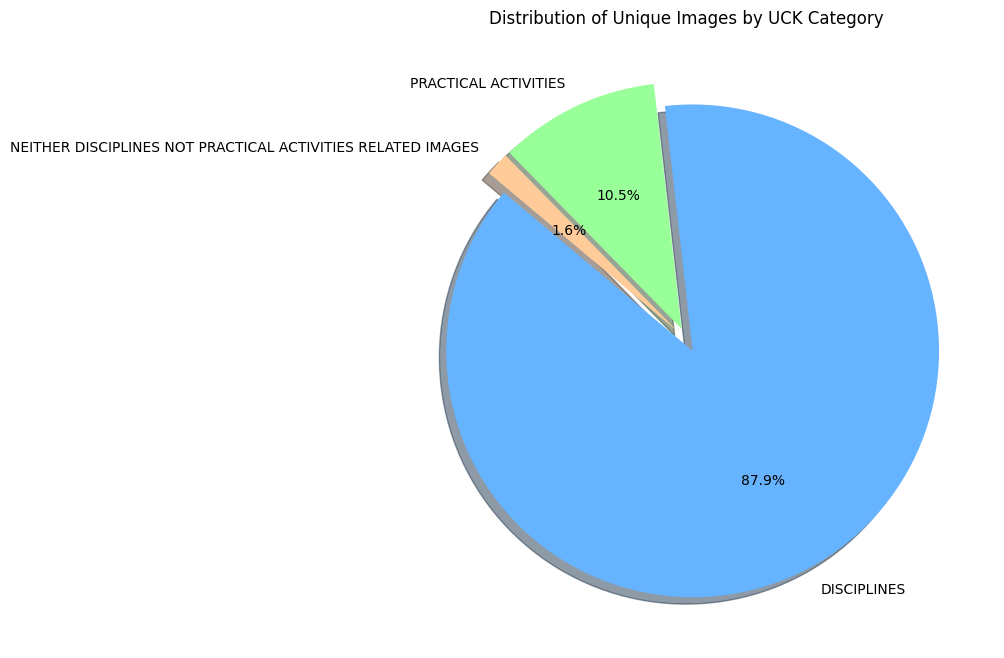

In [8]:
import matplotlib.pyplot as plt

# Unique images in DISCIPLINES
disciplines_images = df_merged[df_merged['uck'].str.contains('DISCIPLINES', case=False)]['images'].unique()
disciplines_count = len(disciplines_images)

# Unique images in PRACTICAL ACTIVITIES
practical_images = df_merged[df_merged['uck'].str.contains('PRACTICAL ACTIVITIES', case=False)]['images'].unique()
practical_count = len(practical_images)

# Unique images not in DISCIPLINES or PRACTICAL ACTIVITIES
all_disc_prac_images = set(disciplines_images) | set(practical_images)
other_unique_images_count = df_merged[~df_merged['images'].isin(all_disc_prac_images)]['images'].nunique()

# Prepare data for pie chart
pie_data = [disciplines_count, practical_count, other_unique_images_count]
labels = ['DISCIPLINES', 'PRACTICAL ACTIVITIES', 'NEITHER DISCIPLINES NOT PRACTICAL ACTIVITIES RELATED IMAGES']
colors = ['#66b3ff', '#99ff99', '#ffcc99']  # optional: distinct colorsa
explode = (0.05, 0.05, 0.05)  # optional: slightly separate slices

# Plot pie chart
plt.figure(figsize=(8,8))
plt.pie(pie_data, labels=labels, autopct='%1.1f%%', startangle=140, colors=colors, explode=explode, shadow=True)
plt.title('Distribution of Unique Images by UCK Category')

plt.savefig('/Users/nogashlomi/Desktop/not_text_paper/ucks_pie_chart.png', dpi=300)

plt.show()


In [9]:
import pandas as pd

# List of disciplines
disciplines = ['Astronomy', 'Geometry', 'Cosmography and Geography', 'Optics', 'Arithmetic', 'Mechanics', 'Meteorology', 'Music']

# Count of images per discipline (including duplicates)
images_per_discipline = {d: df_merged[df_merged['uck'] == d]['images'].nunique() for d in disciplines}

# Convert to Series for plotting
images_per_discipline = pd.Series(images_per_discipline).sort_values(ascending=False)
print(images_per_discipline)


Astronomy                    15038
Geometry                      5773
Cosmography and Geography     1503
Optics                         863
Meteorology                    331
Arithmetic                      56
Mechanics                       25
Music                            1
dtype: int64


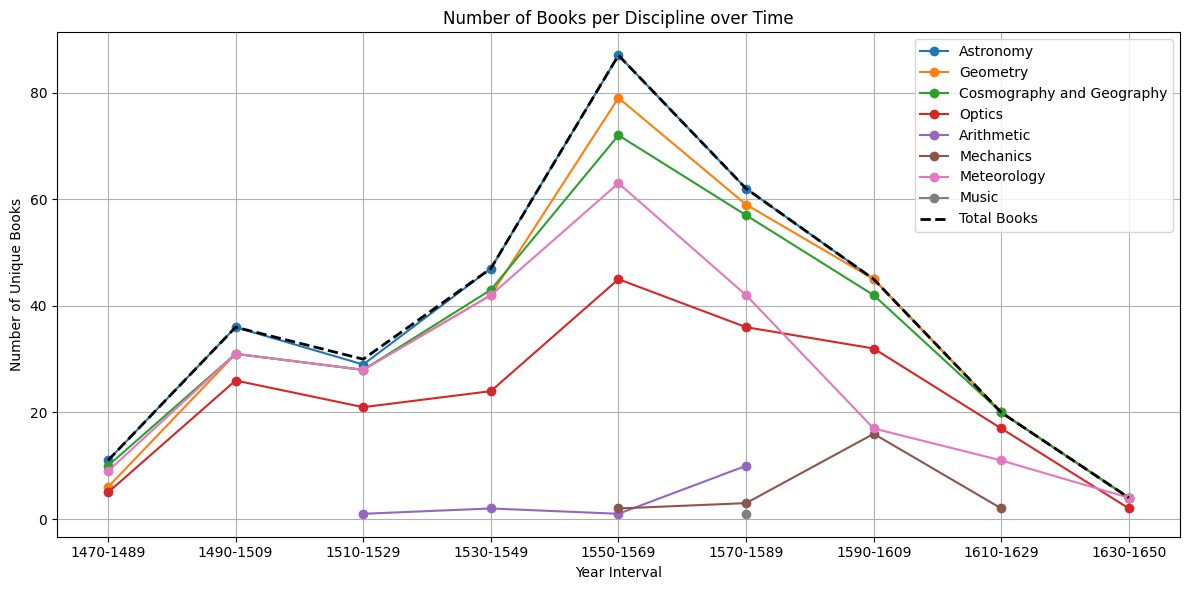

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# Define disciplines, including combined category
disciplines = ['Astronomy', 'Geometry', 'Cosmography and Geography', 
               'Optics', 'Arithmetic', 'Mechanics', 'Meteorology', 'Music']

# Prepare counts per discipline per year_interval (unique books)
temporal_counts = pd.DataFrame()
for d in disciplines:
    if d == 'Cosmography and Geography':
        mask = df_merged['uck'].isin(['Cosmography and Geography'])
    else:
        mask = df_merged['uck'] == d
    counts = df_merged[mask].groupby('year_interval')['book'].nunique()
    counts = counts[counts > 0]  # exclude zeros
    temporal_counts[d] = counts

temporal_counts = temporal_counts.sort_index()

# Total number of books per year_interval
total_books = df_merged.groupby('year_interval')['book'].nunique()
total_books = total_books[total_books > 0]

# Plot simple line graph with total books as black dashed line
plt.figure(figsize=(12,6))
for d in temporal_counts.columns:
    plt.plot(temporal_counts.index, temporal_counts[d], marker='o', label=d)

plt.plot(total_books.index, total_books.values, 'k--', linewidth=2, label='Total Books')

plt.xlabel('Year Interval')
plt.ylabel('Number of Unique Books')
plt.title('Number of Books per Discipline over Time')
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig('/Users/nogashlomi/Desktop/not_text_paper/disciplines_lines.png', dpi=300)


plt.show()


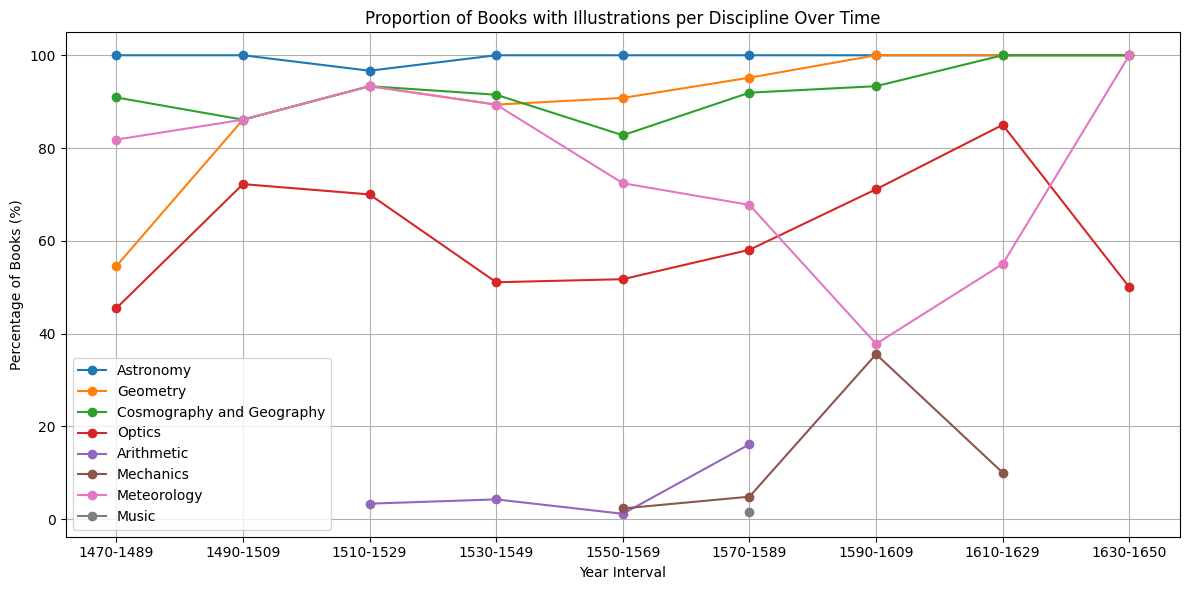

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# Define disciplines, including combined category
# Define disciplines, including combined category
disciplines = ['Astronomy', 'Geometry', 'Cosmography and Geography', 
               'Optics', 'Arithmetic', 'Mechanics', 'Meteorology', 'Music']

# Prepare a DataFrame with proportions
proportions = pd.DataFrame()

# Total number of books per year_interval
total_books = df_merged.groupby('year_interval')['book'].nunique()

for d in disciplines:
    if d == 'Cosmography and Geography':
        mask = df_merged['uck'].isin(['Cosmography and Geography'])
    else:
        mask = df_merged['uck'] == d
    counts = df_merged[mask].groupby('year_interval')['book'].nunique()
    # Only keep year intervals that exist in total_books
    counts = counts[counts.index.isin(total_books.index)]
    # Compute proportion in percentage
    proportions[d] = (counts / total_books[counts.index]) * 100

# Sort by year_interval
proportions = proportions.sort_index()

# Plot
plt.figure(figsize=(12,6))
for d in proportions.columns:
    plt.plot(proportions.index, proportions[d], marker='o', label=d)

plt.xlabel('Year Interval')
plt.ylabel('Percentage of Books (%)')
plt.title('Proportion of Books with Illustrations per Discipline Over Time')
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig('/Users/nogashlomi/Desktop/not_text_paper/disciplines_proportional_lines.png', dpi=300)


plt.show()


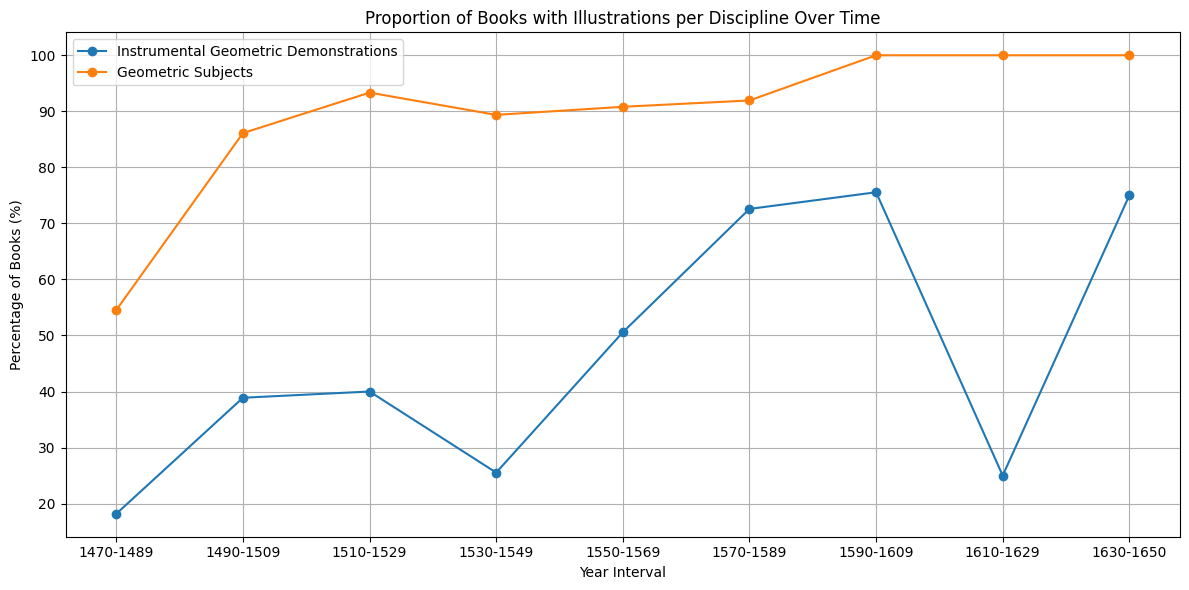

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# Define disciplines, including combined category
disciplines = ['Instrumental Geometric Demonstrations', 
               'Geometric Subjects']


# Prepare a DataFrame with proportions
proportions = pd.DataFrame()

# Total number of books per year_interval
total_books = df_merged.groupby('year_interval')['book'].nunique()

for d in disciplines:
    if d == 'Cosmography and Geography':
        mask = df_merged['uck'].isin(['Cosmography and Geography'])
    else:
        mask = df_merged['uck'] == d
    counts = df_merged[mask].groupby('year_interval')['book'].nunique()
    # Only keep year intervals that exist in total_books
    counts = counts[counts.index.isin(total_books.index)]
    # Compute proportion in percentage
    proportions[d] = (counts / total_books[counts.index]) * 100

# Sort by year_interval
proportions = proportions.sort_index()

# Plot
plt.figure(figsize=(12,6))
for d in proportions.columns:
    plt.plot(proportions.index, proportions[d], marker='o', label=d)

plt.xlabel('Year Interval')
plt.ylabel('Percentage of Books (%)')
plt.title('Proportion of Books with Illustrations per Discipline Over Time')
plt.legend()
plt.grid(True)
plt.tight_layout()

# plt.savefig('/Users/nogashlomi/Desktop/not_text_paper/disciplines_proportional_lines.png', dpi=300)


plt.show()


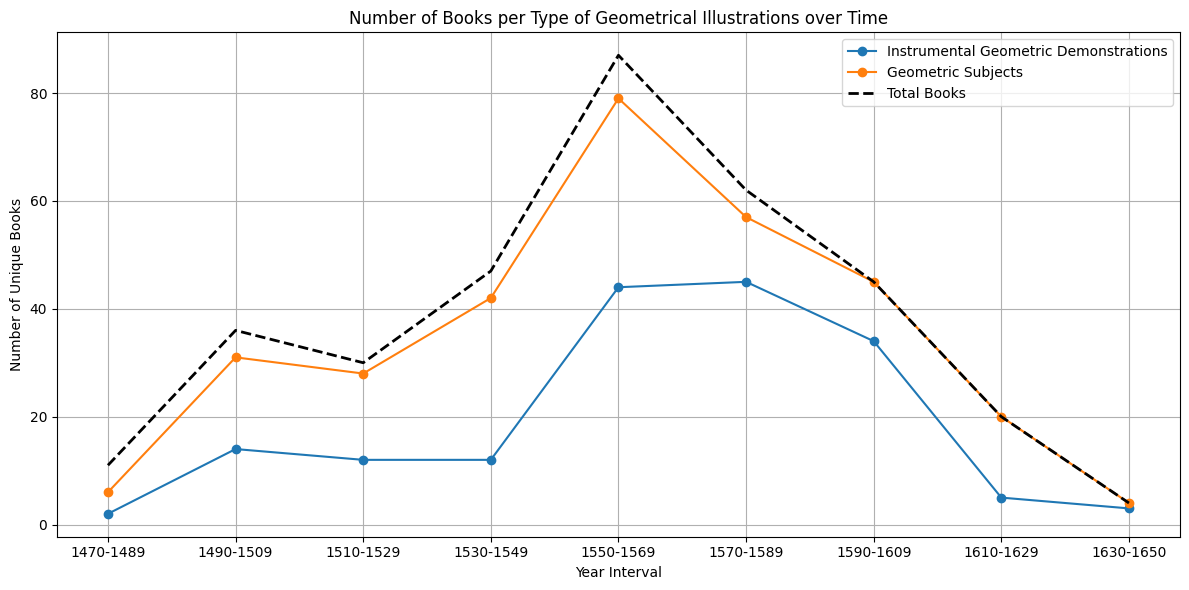

In [13]:


import pandas as pd
import matplotlib.pyplot as plt

# Define disciplines, including combined category
disciplines = ['Instrumental Geometric Demonstrations', 
               'Geometric Subjects']

# Prepare counts per discipline per year_interval (unique books)
temporal_counts = pd.DataFrame()
for d in disciplines:
    if d == 'Cosmography and Geography':
        mask = df_merged['uck'].isin(['Cosmography and Geography'])
    else:
        mask = df_merged['uck'] == d
    counts = df_merged[mask].groupby('year_interval')['book'].nunique()
    counts = counts[counts > 0]  # exclude zeros
    temporal_counts[d] = counts

temporal_counts = temporal_counts.sort_index()

# Total number of books per year_interval
total_books = df_merged.groupby('year_interval')['book'].nunique()
total_books = total_books[total_books > 0]

# Plot simple line graph with total books as black dashed line
plt.figure(figsize=(12,6))
for d in temporal_counts.columns:
    plt.plot(temporal_counts.index, temporal_counts[d], marker='o', label=d)

plt.plot(total_books.index, total_books.values, 'k--', linewidth=2, label='Total Books')

plt.xlabel('Year Interval')
plt.ylabel('Number of Unique Books')
plt.title('Number of Books per Type of Geometrical Illustrations over Time')
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig('/Users/nogashlomi/Desktop/not_text_paper/geonetry_lines.png', dpi=300)


plt.show()


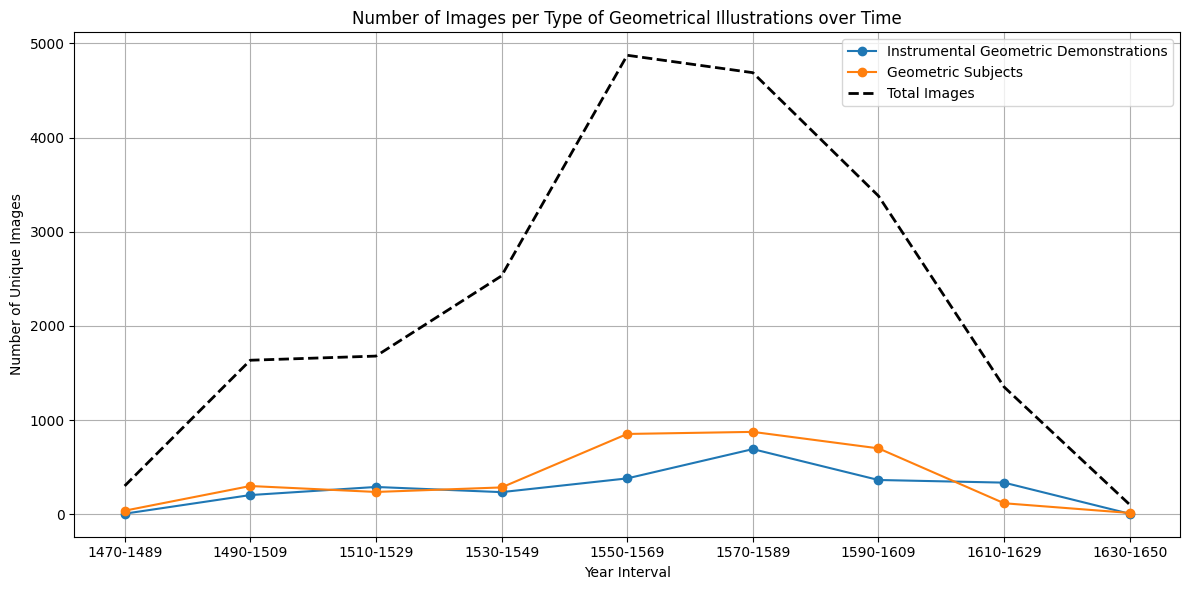

In [14]:


import pandas as pd
import matplotlib.pyplot as plt

# Define disciplines, including combined category
disciplines = ['Instrumental Geometric Demonstrations', 
               'Geometric Subjects']

# Prepare counts per discipline per year_interval (unique books)
temporal_counts = pd.DataFrame()
for d in disciplines:
    if d == 'Cosmography and Geography':
        mask = df_merged['uck'].isin(['Cosmography and Geography'])
    else:
        mask = df_merged['uck'] == d
    counts = df_merged[mask].groupby('year_interval')['images'].nunique()
    counts = counts[counts > 0]  # exclude zeros
    temporal_counts[d] = counts

temporal_counts = temporal_counts.sort_index()

# Total number of books per year_interval
total_books = df_merged.groupby('year_interval')['images'].nunique()
total_books = total_books[total_books > 0]

# Plot simple line graph with total books as black dashed line
plt.figure(figsize=(12,6))
for d in temporal_counts.columns:
    plt.plot(temporal_counts.index, temporal_counts[d], marker='o', label=d)

plt.plot(total_books.index, total_books.values, 'k--', linewidth=2, label='Total Images')

plt.xlabel('Year Interval')
plt.ylabel('Number of Unique Images')
plt.title('Number of Images per Type of Geometrical Illustrations over Time')
plt.legend()
plt.grid(True)
plt.tight_layout()

# plt.savefig('/Users/nogashlomi/Desktop/not_text_paper/geonetry_lines.png', dpi=300)


plt.show()


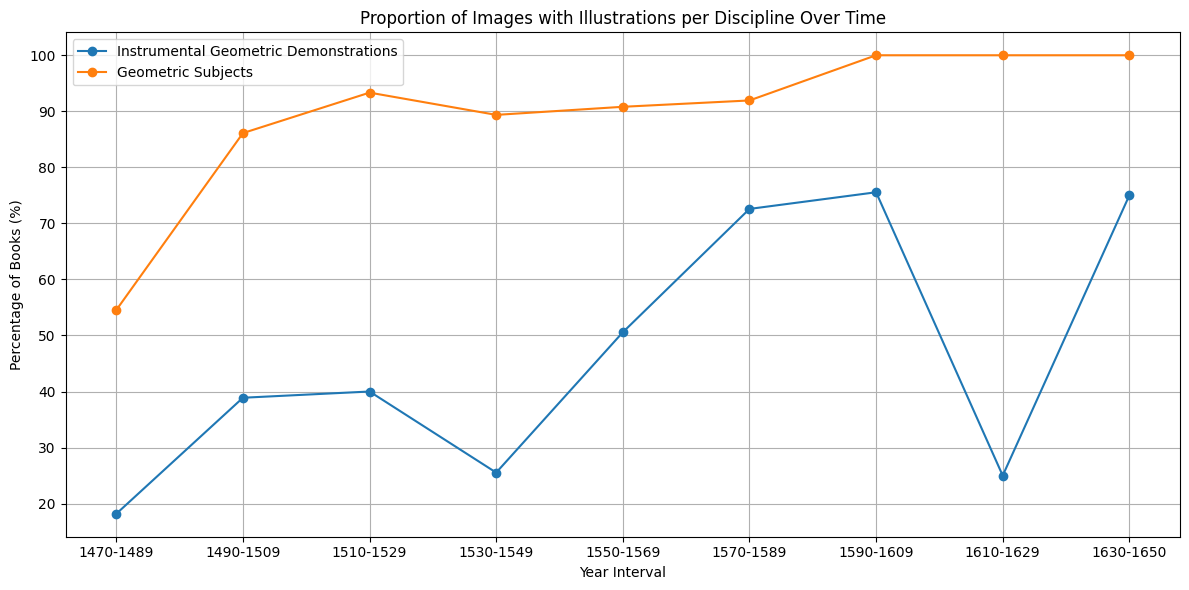

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# Define disciplines, including combined category
disciplines = ['Instrumental Geometric Demonstrations', 
               'Geometric Subjects']


# Prepare a DataFrame with proportions
proportions = pd.DataFrame()

# Total number of books per year_interval
total_books = df_merged.groupby('year_interval')['book'].nunique()

for d in disciplines:
    if d == 'Cosmography and Geography':
        mask = df_merged['uck'].isin(['Cosmography and Geography'])
    else:
        mask = df_merged['uck'] == d
    counts = df_merged[mask].groupby('year_interval')['book'].nunique()
    # Only keep year intervals that exist in total_books
    counts = counts[counts.index.isin(total_books.index)]
    # Compute proportion in percentage
    proportions[d] = (counts / total_books[counts.index]) * 100

# Sort by year_interval
proportions = proportions.sort_index()

# Plot
plt.figure(figsize=(12,6))
for d in proportions.columns:
    plt.plot(proportions.index, proportions[d], marker='o', label=d)

plt.xlabel('Year Interval')
plt.ylabel('Percentage of Books (%)')
plt.title('Proportion of Images with Illustrations per Discipline Over Time')
plt.legend()
plt.grid(True)
plt.tight_layout()

# plt.savefig('/Users/nogashlomi/Desktop/not_text_paper/disciplines_proportional_lines.png', dpi=300)


plt.show()


In [16]:
import pandas as pd

# Define disciplines
disciplines = ['Astronomy', 'Geometry', 'Cosmography and Geography',
               'Optics', 'Arithmetic', 'Mechanics', 'Meteorology', 'Music']

# Create a dictionary to store results
places_per_discipline = {}

for d in disciplines:
    if d == 'Cosmography and Geography':
        mask = df_merged['uck'].isin(['Cosmography and Geography'])
    else:
        mask = df_merged['uck'] == d
        
    # Group by place and count unique books
    counts = df_merged[mask].groupby('place')['book'].nunique().sort_values(ascending=False)
    
    places_per_discipline[d] = counts

# Print results
for d, counts in places_per_discipline.items():
    print(f"\nDiscipline: {d}")
    print(counts)



Discipline: Astronomy
place
Venice                        68
Paris                         67
Wittenberg                    48
Antwerp                       22
Leipzig                       19
Lyon                          16
Cologne                       15
Frankfurt (Main)              13
London                        10
Rome                           6
Strasbourg                     5
Seville                        5
Leiden                         4
Florence                       3
Kraków                         3
Saint Gervais                  3
Lisbon                         3
Perugia                        2
Milan                          2
Dijon                          2
Basel                          2
Sine loco                      2
Valladolid                     2
Salamanca                      1
Padua                          1
Avignon                        1
Vienna                         1
Siena                          1
Mexico City                    1
Nuremberg     

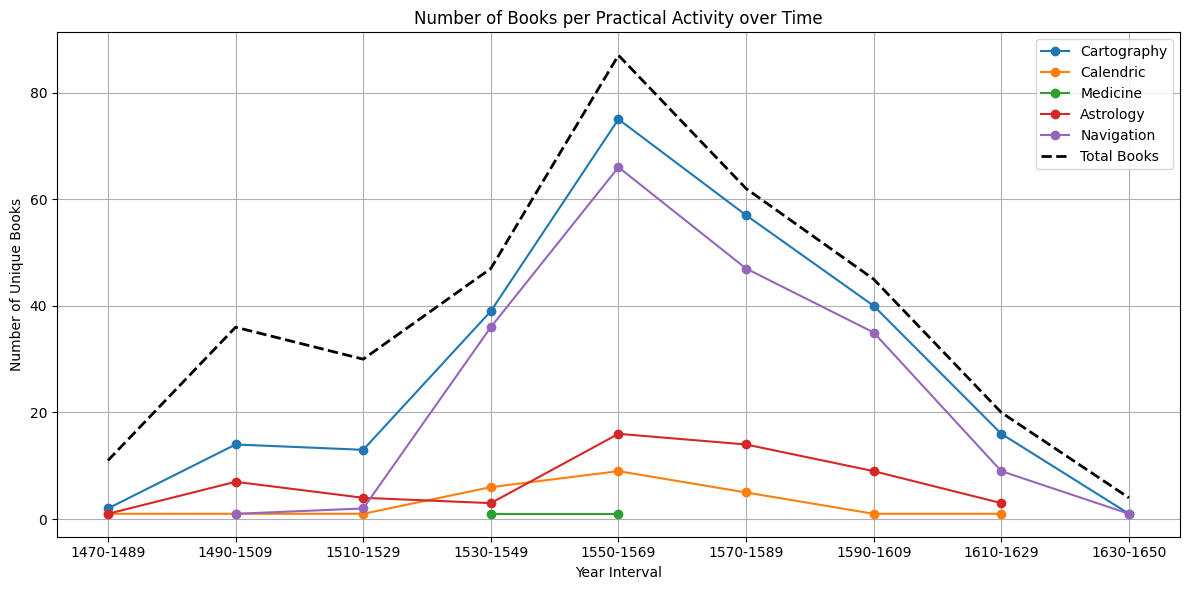

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

# Define practical activities
practical_activities = ['Cartography', 'Calendric', 'Medicine', 'Astrology', 'Navigation']

# Prepare counts per practical activity per year_interval (unique books)
temporal_counts_practical = pd.DataFrame()
for p in practical_activities:
    mask = df_merged['uck'] == p
    counts = df_merged[mask].groupby('year_interval')['book'].nunique()
    counts = counts[counts > 0]  # exclude zeros
    temporal_counts_practical[p] = counts

temporal_counts_practical = temporal_counts_practical.sort_index()

# Total number of books per year_interval (same as before)
total_books = df_merged.groupby('year_interval')['book'].nunique()
total_books = total_books[total_books > 0]

# Plot line graph with total books as black dashed line
plt.figure(figsize=(12,6))
for p in temporal_counts_practical.columns:
    plt.plot(temporal_counts_practical.index, temporal_counts_practical[p], marker='o', label=p)

plt.plot(total_books.index, total_books.values, 'k--', linewidth=2, label='Total Books')

plt.xlabel('Year Interval')
plt.ylabel('Number of Unique Books')
plt.title('Number of Books per Practical Activity over Time')
plt.legend()
plt.grid(True)
plt.tight_layout()

# Save figure
plt.savefig('/Users/nogashlomi/Desktop/not_text_paper/practical_activities_lines.png', dpi=300)

plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Define practical activities
practical_activities = ['Cartography', 'Calendric', 'Medicine', 'Astrology', 'Navigation']

# Prepare a DataFrame with proportions
proportions_practical = pd.DataFrame()

# Total number of books per year_interval
total_books = df_merged.groupby('year_interval')['book'].nunique()

for p in practical_activities:
    mask = df_merged['uck'] == p
    counts = df_merged[mask].groupby('year_interval')['book'].nunique()
    # Only keep year intervals that exist in total_books
    counts = counts[counts.index.isin(total_books.index)]
    # Compute proportion in percentage
    proportions_practical[p] = (counts / total_books[counts.index]) * 100

# Sort by year_interval
proportions_practical = proportions_practical.sort_index()

# Plot
plt.figure(figsize=(12,6))
for p in proportions_practical.columns:
    plt.plot(proportions_practical.index, proportions_practical[p], marker='o', label=p)

plt.xlabel('Year Interval')
plt.ylabel('Percentage of Books (%)')
plt.title('Proportion of Books with Illustrations per Practical Activity Over Time')
plt.legend()
plt.grid(True)
plt.tight_layout()

# Save figure
plt.savefig('/Users/nogashlomi/Desktop/not_text_paper/practical_activities_proportional_lines.png', dpi=300)

plt.show()


In [ ]:
# Define practical activities
practical_activities = ['Cartography', 'Calendric', 'Medicine', 'Astrology', 'Navigation']

# Dictionary to store results
places_stats_per_practical = {}

# Total books per place
total_books_per_place = df_merged.groupby('place')['book'].nunique()

for p in practical_activities:
    mask = df_merged['uck'] == p
    df_activity = df_merged[mask]
    
    # Unique books per place
    books_per_place = df_activity.groupby('place')['book'].nunique()
    
    # Percentage of total books in that city
    percent_per_place = (books_per_place / total_books_per_place[books_per_place.index]) * 100
    
    # Earliest year a book with this activity was printed in the city
    earliest_year = df_activity.groupby('place')['year_interval'].min()
    
    # Combine into a DataFrame
    df_stats = pd.DataFrame({
        'Earliest Year': earliest_year,
        'Number of Books': books_per_place,
        'Percentage of Books (%)': percent_per_place
    }).sort_values(by='Earliest Year')  # sort by earliest printed book
    
    places_stats_per_practical[p] = df_stats

# Print results
for p, df_stats in places_stats_per_practical.items():
    print(f"\nPractical Activity: {p}")
    print(df_stats)


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Filter for uck == 'Navigation'
df_nav = df_merged[df_merged['uck'] == 'Navigation']

# Remove duplicates so each book is plotted once per place/year
df_nav_unique = df_nav.drop_duplicates(subset=['book', 'place', 'year'])

# Create scatter plot with colors by 'place'
plt.figure(figsize=(14, 7))
sns.scatterplot(
    data=df_nav_unique,
    x='year',
    y='place',
    hue='place',       # different color for each place
    palette='tab20',   # nice categorical palette
    s=100,             # size of the dots
    legend='full'
)

plt.xlabel('Year')
plt.ylabel('Place')
plt.title('Books Including Navigation Related Illustrations by City of Print Over Time')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')  # move legend outside plot
plt.tight_layout()

plt.savefig('/Users/nogashlomi/Desktop/not_text_paper/navigation_places.png', dpi=300)


plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Filter for uck == 'Navigation'
df_nav = df_merged[df_merged['uck'] == 'Cosmography and Geography']

# Remove duplicates so each book is plotted once per place/year
df_nav_unique = df_nav.drop_duplicates(subset=['book', 'place', 'year'])

# Create scatter plot with colors by 'place'
plt.figure(figsize=(14, 7))
sns.scatterplot(
    data=df_nav_unique,
    x='year',
    y='place',
    hue='place',       # different color for each place
    palette='tab20',   # nice categorical palette
    s=100,             # size of the dots
    legend='full'
)

plt.xlabel('Year')
plt.ylabel('Place')
plt.title('Cosmography and Geography Books by Year and Place')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')  # move legend outside plot
plt.tight_layout()
plt.savefig('/Users/nogashlomi/Desktop/not_text_paper/Cosmography and Geography_places.png', dpi=300)
plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Filter for uck == 'Navigation'
df_nav = df_merged[df_merged['uck'] == 'Mechanics']

# Remove duplicates so each book is plotted once per place/year
df_nav_unique = df_nav.drop_duplicates(subset=['book', 'place', 'year'])

# Create scatter plot with colors by 'place'
plt.figure(figsize=(14, 7))
sns.scatterplot(
    data=df_nav_unique,
    x='year',
    y='place',
    hue='place',       # different color for each place
    palette='tab20',   # nice categorical palette
    s=100,             # size of the dots
    legend='full'
)

plt.xlabel('Year')
plt.ylabel('Place')
plt.title('Mechanics Books by Year and Place')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')  # move legend outside plot
plt.tight_layout()

plt.savefig('/Users/nogashlomi/Desktop/not_text_paper/Mechanics_places.png', dpi=300)


plt.show()


In [ ]:
import plotly.express as px
import pandas as pd

# Keep only unique places from the full dataset
df_places = df_merged.drop_duplicates(subset=['place','latitude','longitude']).dropna(subset=['latitude','longitude'])

# Optional: restrict to Europe extent (rough bounding box)
df_places = df_places[
    (df_places['longitude'] >= -10) & (df_places['longitude'] <= 30) &
    (df_places['latitude'] >= 35) & (df_places['latitude'] <= 60)
]

# Create interactive map
fig = px.scatter_mapbox(
    df_places,
    lat="latitude",
    lon="longitude",
    hover_name="place",      # shows place on hover
    zoom=3,                  # initial zoom
    height=700               # height of map
)

# Use a clean map style and remove margins
fig.update_layout(
    mapbox_style="carto-positron",
    margin={"r":0,"t":0,"l":0,"b":0}
)

# Show map
fig.show()


In [ ]:
import plotly.express as px
import pandas as pd

# Keep unique places with latitude/longitude
df_places = df_merged.dropna(subset=['latitude', 'longitude'])

# Flag places that have at least one Navigation uck
navigation_places = df_places[df_places['uck'] == 'Navigation']['place'].unique()
df_places['is_navigation'] = df_places['place'].isin(navigation_places)

# Keep only one row per place
df_places_unique = df_places.drop_duplicates(subset=['place','latitude','longitude'])

# Restrict to Europe extent
df_places_unique = df_places_unique[
    (df_places_unique['longitude'] >= -10) & (df_places_unique['longitude'] <= 30) &
    (df_places_unique['latitude'] >= 35) & (df_places_unique['latitude'] <= 60)
]

# Create map
fig = px.scatter_mapbox(
    df_places_unique,
    lat="latitude",
    lon="longitude",
    hover_name="place",
    color="is_navigation",
    color_discrete_map={True: "red", False: "blue"},
    zoom=3,
    height=700
)

fig.update_layout(
    mapbox_style="carto-positron",
    margin={"r":0,"t":0,"l":0,"b":0},
    legend_title_text='Navigation UCK'
)

plt.savefig('/Users/nogashlomi/Desktop/not_text_paper/navigation_map.png', dpi=300)

fig.show()


In [ ]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# --- Configuration ---
uck_values_to_include = [
    "Astronomy", "Geometry", "Cosmography and Geography", "Optics",
    "Arithmetic", "Mechanics", "Music", "Meteorology",
    "Astrology", "Navigation", "Medicine", "Calendric", "Cartography"
]

# --- Prepare nodes ---
uck_nodes = uck_values_to_include
printer_nodes = df_merged['printer'].dropna().unique().tolist()
publisher_nodes = df_merged['publisher'].dropna().unique().tolist()
other_nodes = list(set(printer_nodes + publisher_nodes))

# --- Create bipartite edges ---
edges = []
for uck in uck_nodes:
    df_subset = df_merged[df_merged['uck'] == uck]
    printers_publishers = pd.concat([df_subset['printer'], df_subset['publisher']]).dropna().unique()
    for pp in printers_publishers:
        edges.append((uck, pp))

# --- Create graph ---
B = nx.Graph()
B.add_nodes_from(uck_nodes, bipartite=0)
B.add_nodes_from(other_nodes, bipartite=1)
B.add_edges_from(edges)

# --- Node colors ---
import matplotlib.pyplot as plt
place_category_map = dict(
    zip(
        df_merged['place_category'].dropna().unique(),
        plt.colormaps['tab20'].colors[:len(df_merged['place_category'].dropna().unique())]
    )
)

node_colors = []
for node in B.nodes():
    if node in uck_nodes:
        node_colors.append('grey')
    else:
        category = df_merged.loc[
            (df_merged['printer'] == node) | (df_merged['publisher'] == node),
            'place_category'
        ].dropna().unique()
        if len(category) > 0:
            node_colors.append(place_category_map[category[0]])
        else:
            node_colors.append('lightgrey')

# --- Layout with clustering ---
pos = nx.spring_layout(B, k=0.5, iterations=100, seed=42)  # k controls spacing

# Plot
plt.figure(figsize=(20,14))
nx.draw(
    B,
    pos,
    with_labels=True,
    node_color=node_colors,
    node_size=700,
    edge_color='black',
    font_size=8
)
plt.title("Bipartite Network: UCKs and Printers/Publishers (Clustered Layout)")
plt.show()


In [ ]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# --- Configuration ---
uck_values_to_include = [
    "Astronomy", "Geometry", "Cosmography and Geography", "Optics",
    "Arithmetic", "Mechanics", "Music", "Meteorology",
    "Astrology", "Navigation", "Medicine", "Calendric", "Cartography"
]

# --- Prepare nodes ---
uck_nodes = uck_values_to_include
place_nodes = df_merged['place'].dropna().unique().tolist()

# --- Create bipartite edges ---
edges = []
for uck in uck_nodes:
    df_subset = df_merged[df_merged['uck'] == uck]
    places = df_subset['place'].dropna().unique()
    for place in places:
        edges.append((uck, place))

# --- Create graph ---
B = nx.Graph()
B.add_nodes_from(uck_nodes, bipartite=0)
B.add_nodes_from(place_nodes, bipartite=1)
B.add_edges_from(edges)

# --- Node colors ---
# UCK nodes = grey
# Places colored by place_category
import matplotlib.pyplot as plt
place_category_map = dict(
    zip(
        df_merged['place_category'].dropna().unique(),
        plt.colormaps['tab20'].colors[:len(df_merged['place_category'].dropna().unique())]
    )
)

node_colors = []
for node in B.nodes():
    if node in uck_nodes:
        node_colors.append('grey')
    else:
        category = df_merged.loc[df_merged['place'] == node, 'place_category'].dropna().unique()
        if len(category) > 0:
            node_colors.append(place_category_map[category[0]])
        else:
            node_colors.append('lightgrey')

# --- Layout with clustering ---
pos = nx.spring_layout(B, k=0.5, iterations=100, seed=42)  # clustered layout

# --- Plot ---
plt.figure(figsize=(20,14))
nx.draw(
    B,
    pos,
    with_labels=True,
    node_color=node_colors,
    node_size=700,
    edge_color='black',
    font_size=8
)
plt.title("Bipartite Network: UCKs and Places (Clustered Layout)")
plt.show()


In [ ]:
print(df_merged.columns)


In [ ]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# --- Filter your dataset ---
df_filtered = df_merged.dropna(subset=['book', 'place'])

# --- Create the bipartite graph ---
B = nx.Graph()
books = df_filtered['book'].unique()
places = df_filtered['place'].unique()

B.add_nodes_from(books, bipartite=0, type='book')
B.add_nodes_from(places, bipartite=1, type='place')

edges = list(df_filtered[['book', 'place']].itertuples(index=False, name=None))
B.add_edges_from(edges)

# --- Color books by year_interval ---
year_intervals = df_filtered[['book', 'year_interval']].drop_duplicates()
intervals = year_intervals['year_interval'].unique()
color_map = {interval: plt.cm.tab20(i / len(intervals)) for i, interval in enumerate(intervals)}

node_colors = []
for node in B.nodes():
    if B.nodes[node]['type'] == 'book':
        year_interval = year_intervals.loc[year_intervals['book'] == node, 'year_interval'].values[0]
        node_colors.append(color_map[year_interval])
    else:
        node_colors.append('lightgray')  # places in gray

# --- Size place nodes proportional to number of books ---
place_counts = df_filtered.groupby('place')['book'].nunique()
node_sizes = []
for node in B.nodes():
    if B.nodes[node]['type'] == 'book':
        node_sizes.append(150)  # small size for books
    else:
        node_sizes.append(place_counts[node] * 100)  # scale place size by number of books

# --- Force-directed layout with attraction scaling ---
# We'll use the number of books as a weight to make big hubs pull their books closer
edge_weights = [place_counts[edge[1]] if B.nodes[edge[1]]['type'] == 'place' else 1 for edge in B.edges()]

pos = nx.spring_layout(
    B,
    k=0.5,              # optimal distance between nodes
    iterations=200,     # more iterations for stable clusters
    weight=None,        # can use weight=edge_weights for stronger attraction
    seed=42
)

# --- Draw the network ---
plt.figure(figsize=(14, 10))
nx.draw(
    B, pos,
    with_labels=False,       # hide book labels
    node_color=node_colors,
    node_size=node_sizes,
    edge_color='gray',
    alpha=0.6
)

# --- Draw place labels ---
place_labels = {node: node for node in B.nodes() if B.nodes[node]['type'] == 'place'}
nx.draw_networkx_labels(B, pos, labels=place_labels, font_size=10, font_weight='bold')

plt.title("Force-Directed Network of Books and Places of Print (Books Colored by Year Interval)")
plt.axis('off')

plt.savefig('/Users/nogashlomi/Desktop/not_text_paper/place_network.png', dpi=300)


plt.show()


In [ ]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# --- Filter your dataset ---
df_filtered = df_merged.dropna(subset=['book', 'place'])

# --- Create the bipartite graph ---
B = nx.Graph()
books = df_filtered['book'].unique()
places = df_filtered['place'].unique()

B.add_nodes_from(books, bipartite=0, type='book')
B.add_nodes_from(places, bipartite=1, type='place')

edges = list(df_filtered[['book', 'place']].itertuples(index=False, name=None))
B.add_edges_from(edges)

# --- Color books by year_interval ---
year_intervals = df_filtered[['book', 'year_interval']].drop_duplicates()
intervals = sorted(year_intervals['year_interval'].unique())
color_map = {interval: plt.cm.tab20(i / len(intervals)) for i, interval in enumerate(intervals)}

node_colors = []
for node in B.nodes():
    if B.nodes[node]['type'] == 'book':
        year_interval = year_intervals.loc[year_intervals['book'] == node, 'year_interval'].values[0]
        node_colors.append(color_map[year_interval])
    else:
        node_colors.append('lightgray')  # places in gray

# --- Size place nodes proportional to number of books ---
place_counts = df_filtered.groupby('place')['book'].nunique()
node_sizes = []
for node in B.nodes():
    if B.nodes[node]['type'] == 'book':
        node_sizes.append(150)  # small size for books
    else:
        node_sizes.append(place_counts[node] * 100)  # scale place size by number of books

# --- Force-directed layout with attraction scaling ---
edge_weights = [place_counts[edge[1]] if B.nodes[edge[1]]['type'] == 'place' else 1 for edge in B.edges()]

pos = nx.spring_layout(
    B,
    k=0.5,              # optimal distance between nodes
    iterations=200,     # more iterations for stable clusters
    weight=None,        # could use edge_weights for stronger attraction
    seed=42
)

# --- Draw the network ---
plt.figure(figsize=(14, 10))
nx.draw(
    B, pos,
    with_labels=False,       # hide book labels
    node_color=node_colors,
    node_size=node_sizes,
    edge_color='gray',
    alpha=0.6
)

# --- Draw place labels ---
place_labels = {node: node for node in B.nodes() if B.nodes[node]['type'] == 'place'}
nx.draw_networkx_labels(B, pos, labels=place_labels, font_size=10, font_weight='bold')

# --- Add legend for year intervals ---
legend_elements = [Line2D([0], [0], marker='o', color='w', label=interval,
                          markerfacecolor=color_map[interval], markersize=10)
                   for interval in intervals]
plt.legend(handles=legend_elements, title='Year Interval', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.title("Force-Directed Network of Books and Places of Print (Books Colored by Year Interval)")
plt.axis('off')
plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt

# Count books per city
city_counts = df_filtered.groupby('place')['book'].nunique().sort_values(ascending=False)

# Optionally, get the most frequent year_interval for each city for color
city_year = df_filtered.groupby('place')['year_interval'].agg(lambda x: x.value_counts().idxmax())

# Map year_interval to colors
intervals = sorted(df_filtered['year_interval'].unique())
color_map = {interval: plt.cm.tab20(i / len(intervals)) for i, interval in enumerate(intervals)}
city_colors = [color_map[city_year[city]] for city in city_counts.index]

plt.figure(figsize=(14,10))
plt.scatter(
    x=range(len(city_counts)),  # just spread on x-axis
    y=[0]*len(city_counts),     # all on same line
    s=city_counts.values * 50,  # bubble size by number of books
    c=city_colors,
    alpha=0.7
)

# Add city labels
for i, city in enumerate(city_counts.index):
    plt.text(i, 0, city, ha='center', va='center', fontsize=10, fontweight='bold')

# Legend for year_interval
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w', label=interval,
                          markerfacecolor=color_map[interval], markersize=10)
                   for interval in intervals]
plt.legend(handles=legend_elements, title='Most Frequent Year Interval', bbox_to_anchor=(1.05,1), loc='upper left')

plt.title("Cities of Print: Bubble Size Shows Number of Books, Color Shows Year Interval")
plt.axis('off')
plt.show()


In [ ]:
import plotly.express as px
import pandas as pd

# Keep unique places with latitude/longitude
df_places = df_merged.dropna(subset=['latitude', 'longitude'])

# Flag places that have at least one Navigation uck (use .loc to avoid SettingWithCopyWarning)
navigation_places = df_places[df_places['uck'] == 'Navigation']['place'].unique()
df_places.loc[:, 'is_navigation'] = df_places['place'].isin(navigation_places)

# Keep only one row per place
df_places_unique = df_places.drop_duplicates(subset=['place','latitude','longitude'])

# Restrict to Europe extent
df_places_unique = df_places_unique[
    (df_places_unique['longitude'] >= -10) & (df_places_unique['longitude'] <= 30) &
    (df_places_unique['latitude'] >= 35) & (df_places_unique['latitude'] <= 60)
]

# Create map using scatter_map (replaces deprecated scatter_mapbox)
fig = px.scatter_map(
    df_places_unique,
    lat="latitude",
    lon="longitude",
    hover_name="place",
    color="is_navigation",
    color_discrete_map={True: "red", False: "blue"},
    zoom=3,
    height=700
)

fig.update_layout(
    mapbox_style="white-bg",  # minimal map without modern borders
    margin={"r":0,"t":0,"l":0,"b":0},
    legend_title_text='Navigation UCK'
)

fig.show()


In [ ]:
import matplotlib.pyplot as plt

# Unique images in Astronomy
astronomy_images = df_merged[df_merged['uck'].str.contains('Astronomy', case=False)]['images'].unique()
astronomy_count = len(astronomy_images)

# Unique images NOT in Astronomy
other_images_count = df_merged[~df_merged['images'].isin(astronomy_images)]['images'].nunique()

# Prepare data for pie chart
pie_data = [astronomy_count, other_images_count]
labels = ['Astronomy', 'Not Astronomy']
colors = ['#66b3ff', '#ff9999']  # optional: distinct colors
explode = (0.05, 0.05)  # optional: slightly separate slices

# Plot pie chart
plt.figure(figsize=(8,8))
plt.pie(pie_data, labels=labels, autopct='%1.1f%%', startangle=140, colors=colors, explode=explode, shadow=True)
plt.title('Distribution of Unique Images: Astronomy vs Others')

# Save figure
plt.savefig('/Users/nogashlomi/Desktop/not_text_paper/astronomy_vs_others_pie_chart.png', dpi=300)

plt.show()


In [ ]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pandas as pd

# Keep unique places with latitude/longitude
df_places = df_merged.dropna(subset=['latitude', 'longitude'])

# Flag places that have at least one Navigation uck
navigation_places = df_places[df_places['uck'] == 'Navigation']['place'].unique()
df_places['is_navigation'] = df_places['place'].isin(navigation_places)

# Keep only one row per place
df_places_unique = df_places.drop_duplicates(subset=['place','latitude','longitude'])

# Restrict to Europe extent
df_places_unique = df_places_unique[
    (df_places_unique['longitude'] >= -10) & (df_places_unique['longitude'] <= 30) &
    (df_places_unique['latitude'] >= 35) & (df_places_unique['latitude'] <= 60)
]

# Create static map
fig = plt.figure(figsize=(12,10))
ax = plt.axes(projection=ccrs.PlateCarree())

# Set extent to Europe
ax.set_extent([-10, 30, 35, 60])

# Add minimal features
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
# optional: add coastlines without borders
ax.coastlines(resolution='110m', color='black')

# Plot points
ax.scatter(
    df_places_unique['longitude'], 
    df_places_unique['latitude'], 
    c=df_places_unique['is_navigation'].map({True:'red', False:'blue'}),
    s=50,
    alpha=0.7,
    transform=ccrs.PlateCarree(),
    label='Navigation'  # legend will be added manually
)

# Custom legend
import matplotlib.patches as mpatches
red_patch = mpatches.Patch(color='red', label='Navigation')
blue_patch = mpatches.Patch(color='blue', label='Other')
plt.legend(handles=[red_patch, blue_patch], loc='lower left')

plt.title("European Places with Navigation UCK")
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pandas as pd
from adjustText import adjust_text  # pip install adjustText

# Keep unique places with latitude/longitude
df_places = df_merged.dropna(subset=['latitude', 'longitude'])

# Flag places that have at least one Navigation uck
navigation_places = df_places[df_places['uck'] == 'Navigation']['place'].unique()
df_places.loc[:, 'is_navigation'] = df_places['place'].isin(navigation_places)

# Keep only one row per place
df_places_unique = df_places.drop_duplicates(subset=['place','latitude','longitude'])

# Restrict to Europe extent
df_places_unique = df_places_unique[
    (df_places_unique['longitude'] >= -10) & (df_places_unique['longitude'] <= 30) &
    (df_places_unique['latitude'] >= 35) & (df_places_unique['latitude'] <= 60)
]

# Create map
fig = plt.figure(figsize=(12,10))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([-10, 30, 35, 60])

# Add features
ax.add_feature(cfeature.LAND, facecolor='#f0e4d7')
ax.add_feature(cfeature.OCEAN, facecolor='#a6cee3')
ax.add_feature(cfeature.RIVERS, edgecolor='#66c2a5', linewidth=1)
ax.add_feature(cfeature.COASTLINE, edgecolor='black', linewidth=0.8)
ax.add_feature(cfeature.LAKES, facecolor='#a6cee3', edgecolor='black', linewidth=0.5)

# Plot points
ax.scatter(
    df_places_unique['longitude'],
    df_places_unique['latitude'],
    c=df_places_unique['is_navigation'].map({True:'red', False:'blue'}),
    s=60,
    alpha=0.8,
    edgecolors='k',
    transform=ccrs.PlateCarree()
)

# Add city names with adjustText to avoid overlaps
texts = []
for idx, row in df_places_unique.iterrows():
    texts.append(
        ax.text(
            row['longitude'], 
            row['latitude'], 
            row['place'], 
            fontsize=7, 
            weight='bold', 
            transform=ccrs.PlateCarree()
        )
    )

adjust_text(
    texts, 
    only_move={'points':'y', 'text':'xy'}, 
    arrowprops=dict(arrowstyle='-', color='gray', lw=0.5),
    expand_points=(1.2,1.2),
    force_points=0.3
)

# Legend at top-right
import matplotlib.patches as mpatches
red_patch = mpatches.Patch(color='red', label='Navigation')
blue_patch = mpatches.Patch(color='blue', label='Other')
plt.legend(handles=[red_patch, blue_patch], loc='upper right')

plt.title("Navigation Illustrations Across Corpus Cities", fontsize=16)

plt.savefig('/Users/nogashlomi/Desktop/not_text_paper/newplot.png', dpi=300)
plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Define the target cks values
target_cks = [
    'CK_Refraction',
    'CK_Reflection',
    'CK_Burning Mirror',
    'CK_Parallax',
    'CK_Apparent Size of Stars',
    'CK_Twilight'
]

# Prepare counts per cks per year_interval (unique books)
cks_counts = pd.DataFrame()
for cks in target_cks:
    mask = df_merged['cks'] == cks
    counts = df_merged[mask].groupby('year_interval')['book'].nunique()
    counts = counts[counts > 0]  # exclude zeros
    cks_counts[cks] = counts

cks_counts = cks_counts.sort_index()

# Total number of books per year_interval (same as before)
total_books = df_merged.groupby('year_interval')['book'].nunique()
total_books = total_books[total_books > 0]

# Plot line graph with each cks and total books
plt.figure(figsize=(12,6))
for cks in cks_counts.columns:
    plt.plot(cks_counts.index, cks_counts[cks], marker='o', label=cks)

plt.plot(total_books.index, total_books.values, 'k--', linewidth=2, label='Total Books')

plt.xlabel('Year Interval')
plt.ylabel('Number of Unique Books')
plt.title('Number of Books per CK Value over Time')
plt.legend()
plt.grid(True)
plt.tight_layout()

# plt.savefig('/Users/nogashlomi/Desktop/not_text_paper/optics_cks_lines.png', dpi=300)
plt.show()
